## Ejemplo
Problema de minimizacion con restricciones:
$$
\begin{aligned}
\min_{x,y}\quad & (x-2)^2 + (y-3)^2 \\[4pt]
\text{sujeto a}\quad & x+y \geq 6.
\end{aligned}
$$

Note que la funcion objetivo mide el cuadrado de la distancia entre el punto (2,3) y el origen (0,0).

In [13]:
import cvxpy as cp

# Variables simbolicas
x = cp.Variable()
y = cp.Variable()

# La funcion objetivo
# punto original (fuera de la region factible) (2,3)
# punto interior de la region factible (4,4)
# punto en la frontera de la region factible (3,3)
objective = cp.Minimize((x - 3)**2 + (y - 3)**2)

# Las restricciones escritas con expresiones matematicas habituales.
constraints = [
    x + y >= 6,
]

# Creamos el Problema a resolver
problem = cp.Problem(objective, constraints)

# Resolvemos el problema
# Al llamar solve() el objeto problem
# resuelve el problema y crea varios atributos
problem.solve()

# Results
print("Status:", problem.status)
print("Optimal x*:", x.value)
print("Optimal y*:", y.value)
print("Optimal value:", problem.value)

# KKT multiplier (dual variable)
# Karush-Kuhn-Tucker
# lambda se llama el valor dual
print("KKT multiplier:", constraints[0].dual_value)

Status: optimal
Optimal x*: 3.0
Optimal y*: 3.0
Optimal value: 0.0
KKT multiplier: 0.0


In [10]:
# El valor dual es lambda
constraints[0].dual_value

array(0.)

En este caso $λ>0$ eso quiere decir que $g(x*, y*) = 0$, en
otras palabras $x+y = 6$.

### Tenemos la propiedad de **Complementariedad**
En el optimo $(x*,y*)$ y $\lambda*$ tenemos que:
$$\lambda * g(x*,y*) = 0$$

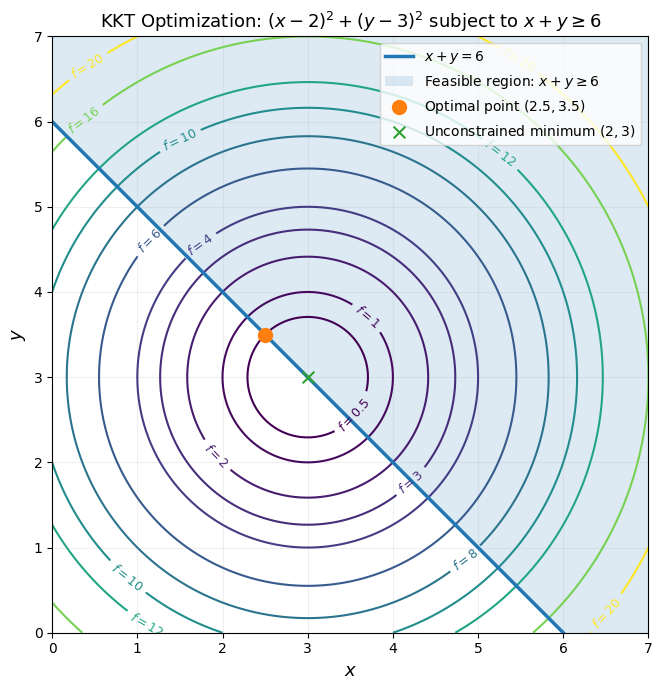

In [14]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Create a grid
x = np.linspace(0, 7, 500)
y = np.linspace(0, 7, 500)
X, Y = np.meshgrid(x, y)

# Objective function
Z = (X - 3)**2 + (Y - 3)**2

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Level curves of the objective function
levels = [0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20]
contours = ax.contour(X, Y, Z, levels=levels)

# Label level curves
ax.clabel(contours, inline=True, fontsize=9,
          fmt=lambda x: f"$f={x:g}$")

# Linear constraint: x + y = 6
ax.plot(x, 6 - x, linewidth=2.5, label=r"$x+y=6$")

# Feasible region: x + y >= 6
ax.fill_between(
    x, 6 - x, 7,
    where=(6 - x <= 7),
    alpha=0.15,
    label=r"Feasible region: $x+y\geq6$"
)

# Optimal point
x_opt = 2.5
y_opt = 3.5

ax.scatter(
    x_opt, y_opt,
    s=100,
    zorder=5,
    label=r"Optimal point $(2.5,3.5)$"
)

# Mark the unconstrained minimum
ax.scatter(
    3, 3,
    s=70,
    marker="x",
    zorder=5,
    label=r"Unconstrained minimum $(2,3)$"
)

# Formatting
ax.set_xlabel("$x$", fontsize=13)
ax.set_ylabel("$y$", fontsize=13)
ax.set_title(
    r"KKT Optimization: $(x-2)^2+(y-3)^2$ subject to $x+y\geq6$",
    fontsize=13
)

ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.set_aspect("equal")

ax.grid(alpha=0.2)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [26]:
import sympy as sp
# Encontrar derivadas automaticamente

# Variables de tipo simbolico
x, y = sp.symbols('x y')

# Function
f = (x - 2)**2 + (sp.atan(y) - 3)**2

# Gradient
gradient = sp.derive_by_array(f, (x, y))

print(gradient)

[2*x - 4, 2*(atan(y) - 3)/(y**2 + 1)]


In [24]:
# la integral respecto a x desde 0 hasta 1
f.integrate((x,0,1), (y,1,2))

14/3